# Lab 2b — Churn Classifiers + the Overfitting Exhibit
**SDA-AIE-111 · Day 2 · Hour 2 · 50 minutes · pairs**

**Objective.** Beat the Lab 1 heuristic with logistic regression; produce the odds-ratio sentence for the CRM team; generate the course's key overfitting plot from your own runs; watch k-NN collapse without scaling.


In [1]:
# --- Course setup (identical in every lab) -----------------------------------
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

def find_repo_root() -> Path:
    """Locate the course repo root by looking for data/manafeth_customers.parquet."""
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "data" / "manafeth_customers.parquet").exists():
            return cand
    raise FileNotFoundError(
        "Course data not found — copy the Manafeth data package files into <repo>/data/")

ROOT = find_repo_root()
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT / "src"))
print("repo root:", ROOT)

repo root: /home/claude/amlf/repo


In [2]:
from sklearn.model_selection import train_test_split

customers = pd.read_parquet(DATA / "manafeth_customers.parquet")
LEAKY = ["refund_issued", "support_ticket_after_snapshot", "next_month_orders"]
X_all = customers.drop(columns=["churned_30d", "customer_id", *LEAKY])
y_all = customers["churned_30d"]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE)

num_cols = ["orders_per_month", "avg_basket_sar", "days_since_last_order",
            "tenure_months", "distinct_categories", "promo_usage_rate"]

# Working split for today (CV replaces this in Module 4)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train[num_cols], y_train, test_size=0.25, stratify=y_train,
    random_state=RANDOM_STATE)

def recall_at_budget(y_true, scores, budget=0.20):
    n = int(budget * len(y_true))
    top = np.argsort(-np.asarray(scores))[:n]
    return np.asarray(y_true)[top].sum() / np.asarray(y_true).sum()

## Task 1 — Logistic regression: the probability is the product *(15 min)*

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

scaler = StandardScaler().fit(X_tr)                 # M3 replaces this with a Pipeline —
X_tr_s, X_val_s = scaler.transform(X_tr), scaler.transform(X_val)   # note fit-on-train-only

clf = LogisticRegression(class_weight="balanced", max_iter=1000,
                         random_state=RANDOM_STATE).fit(X_tr_s, y_tr)

proba = clf.predict_proba(X_val_s)[:, 1]            # the deliverable: a risk score per customer
print("PR-AUC:", round(average_precision_score(y_val, proba), 3), "  [dummy ~0.14]")
print("recall@20%:", round(recall_at_budget(y_val, proba), 2), "  [heuristic ~0.42]")

PR-AUC: 0.482   [dummy ~0.14]
recall@20%: 0.56   [heuristic ~0.42]


## Task 2 — The odds-ratio sentence *(5 min)*

`exp(coef)` on standardised features = the odds multiplier per one standard deviation. Write the one sentence the CRM team would quote.


In [4]:
odds = np.exp(clf.coef_[0])
for name, o in sorted(zip(num_cols, odds), key=lambda t: -abs(np.log(t[1]))):
    print(f"{name:26s} odds x{o:.2f} per +1 std")
# e.g. "Each extra ~11 quiet days multiplies a customer's churn odds by ~2 —
#  recency is the single loudest signal we have."

days_since_last_order      odds x1.62 per +1 std
tenure_months              odds x0.68 per +1 std
promo_usage_rate           odds x1.42 per +1 std
orders_per_month           odds x0.72 per +1 std
distinct_categories        odds x0.73 per +1 std
avg_basket_sar             odds x0.87 per +1 std


## Task 3 — The overfitting exhibit: tree depth sweep *(15 min)*

Training score rises forever; validation tells the truth. This plot is reused all week — Module 7 generalises it into hyperparameter search.


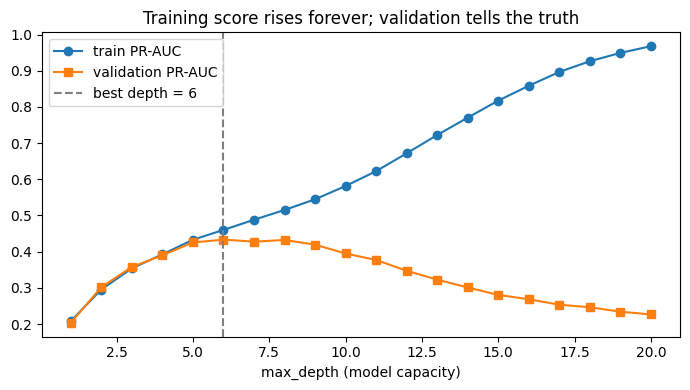

best depth 6: validation PR-AUC 0.433; depth 20 train 0.968 vs validation 0.227 (memorisation)


In [5]:
from sklearn.tree import DecisionTreeClassifier

depths = range(1, 21)
train_scores, val_scores = [], []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, class_weight="balanced",
                                  random_state=RANDOM_STATE).fit(X_tr, y_tr)
    train_scores.append(average_precision_score(y_tr, tree.predict_proba(X_tr)[:, 1]))
    val_scores.append(average_precision_score(y_val, tree.predict_proba(X_val)[:, 1]))

best_d = list(depths)[int(np.argmax(val_scores))]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, train_scores, marker="o", label="train PR-AUC")
ax.plot(depths, val_scores, marker="s", label="validation PR-AUC")
ax.axvline(best_d, ls="--", color="grey", label=f"best depth = {best_d}")
ax.set_xlabel("max_depth (model capacity)")
ax.legend(); ax.set_title("Training score rises forever; validation tells the truth")
plt.tight_layout(); plt.show()
print(f"best depth {best_d}: validation PR-AUC {max(val_scores):.3f}; "
      f"depth 20 train {train_scores[-1]:.3f} vs validation {val_scores[-1]:.3f} (memorisation)")

## Task 4 — k-NN and the scaling collapse *(10 min)*

Distance-based models live or die by feature scale: `tenure_months` (0–60) crushes `promo_usage_rate` (0–1) unless you scale.


In [6]:
from sklearn.neighbors import KNeighborsClassifier

for k in [1, 5, 25, 101]:
    knn_s = KNeighborsClassifier(n_neighbors=k).fit(X_tr_s, y_tr)
    knn_u = KNeighborsClassifier(n_neighbors=k).fit(X_tr, y_tr)
    ps = average_precision_score(y_val, knn_s.predict_proba(X_val_s)[:, 1])
    pu = average_precision_score(y_val, knn_u.predict_proba(X_val)[:, 1])
    print(f"k={k:3d}  scaled PR-AUC {ps:.3f}   unscaled {pu:.3f}")
# k=1 memorises training data (train accuracy 1.0) yet validates poorly;
# unscaled distances are dominated by the widest-range features.

k=  1  scaled PR-AUC 0.203   unscaled 0.204


k=  5  scaled PR-AUC 0.340   unscaled 0.317


k= 25  scaled PR-AUC 0.447   unscaled 0.420


k=101  scaled PR-AUC 0.475   unscaled 0.450


## Task 5 — Commit *(5 min)*

```
git add -A && git commit -m "feat(lab2): linear+logistic beat baselines; overfitting exhibit"
```

**Scoreboard update** — post: logistic PR-AUC, recall@20%, best tree depth.
